# Bellabeat — Share Phase

Build the five visualizations for the executive-facing deliverable, using the small aggregate
tables produced in the Analyze phase (`data/summary/`). Palette: a single blue hue, light -> dark,
for the ordinal activity bands; blue/red diverging for correlation signs.

## Setup

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import os

SUMMARY_DIR = "../data/summary"
PROC_DIR = "../data/processed"
IMG_DIR = "../images"
os.makedirs(IMG_DIR, exist_ok=True)

BLUE = "#2a78d6"
RED = "#e34948"
SEQ = ["#86b6ef", "#5598e7", "#2a78d6", "#184f95"]  # light -> dark, ordinal
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "Segoe UI", "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 12,
})

def clean_axes(ax, hide_y=False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(not hide_y)
    if hide_y:
        ax.yaxis.set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(length=0)

## 1. User activity segmentation

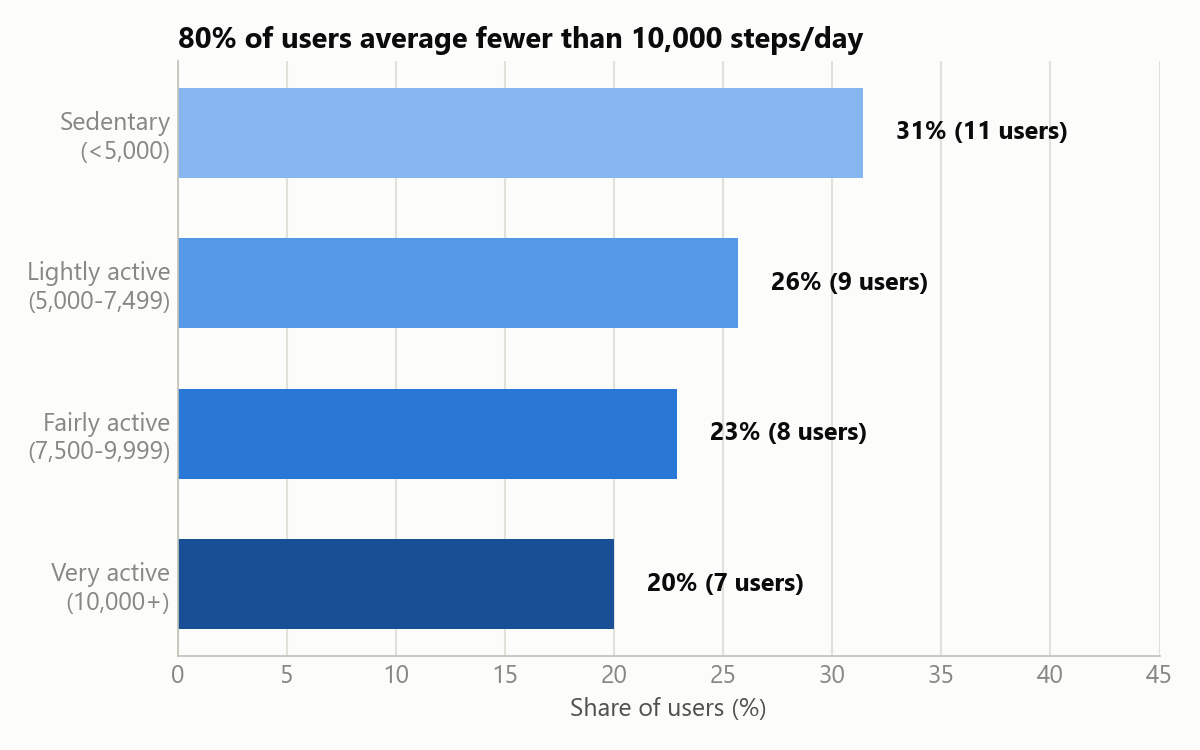

In [2]:
seg = pd.read_csv(os.path.join(SUMMARY_DIR, "user_activity_segments.csv"), index_col=0)
labels = ["Sedentary\n(<5,000)", "Lightly active\n(5,000-7,499)", "Fairly active\n(7,500-9,999)", "Very active\n(10,000+)"]

fig, ax = plt.subplots(figsize=(8, 5))
y = range(len(labels))
ax.barh(y, seg["pct"], color=SEQ, height=0.6)
for i, (n, p) in enumerate(zip(seg["n_users"], seg["pct"])):
    ax.text(p + 1.5, i, f"{p:.0f}% ({int(n)} users)", va="center", fontsize=12, color=INK_PRIMARY, fontweight="bold")
ax.set_yticks(list(y)); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xlim(0, 45); ax.set_xlabel("Share of users (%)")
clean_axes(ax)
ax.xaxis.grid(True, color=GRID, linewidth=1); ax.set_axisbelow(True)
ax.set_title("80% of users average fewer than 10,000 steps/day", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "01_user_activity_segments.png"), dpi=150)
plt.show()

## 2. Where the tracked day goes

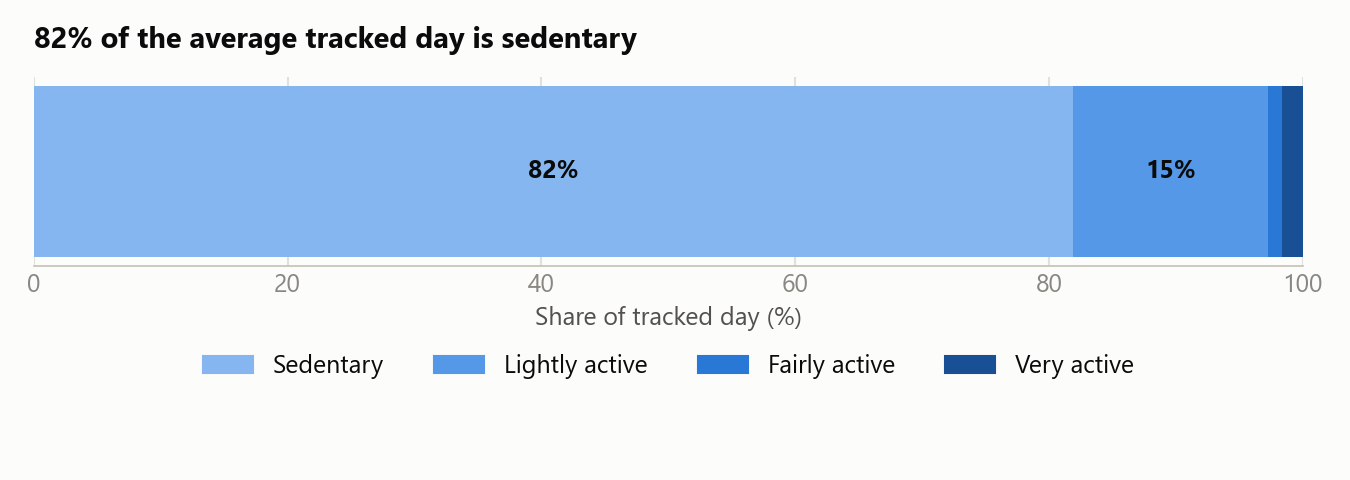

In [3]:
intensity = pd.read_csv(os.path.join(SUMMARY_DIR, "intensity_breakdown.csv"), index_col=0)
order = ["sedentary_minutes", "lightly_active_minutes", "fairly_active_minutes", "very_active_minutes"]
intensity = intensity.loc[order]
labels_stack = ["Sedentary", "Lightly active", "Fairly active", "Very active"]

fig, ax = plt.subplots(figsize=(9, 3.2))
left = 0
for i, (idx, row) in enumerate(intensity.iterrows()):
    ax.barh(0, row["pct_of_day"], left=left, color=SEQ[i], height=0.5)
    if row["pct_of_day"] > 4:
        ax.text(left + row["pct_of_day"]/2, 0, f"{row['pct_of_day']:.0f}%", ha="center", va="center",
                 color="white" if i in (2,3) else INK_PRIMARY, fontsize=12, fontweight="bold")
    left += row["pct_of_day"]
ax.set_yticks([]); ax.set_xlim(0, 100); ax.set_xlabel("Share of tracked day (%)")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(BASELINE); ax.tick_params(length=0)
ax.xaxis.grid(True, color=GRID, linewidth=1); ax.set_axisbelow(True)
ax.set_title("82% of the average tracked day is sedentary", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left", pad=14)
handles = [plt.Rectangle((0,0),1,1, color=c) for c in SEQ]
ax.legend(handles, labels_stack, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=4)
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "02_intensity_breakdown.png"), dpi=150)
plt.show()

## 3. Correlation comparison

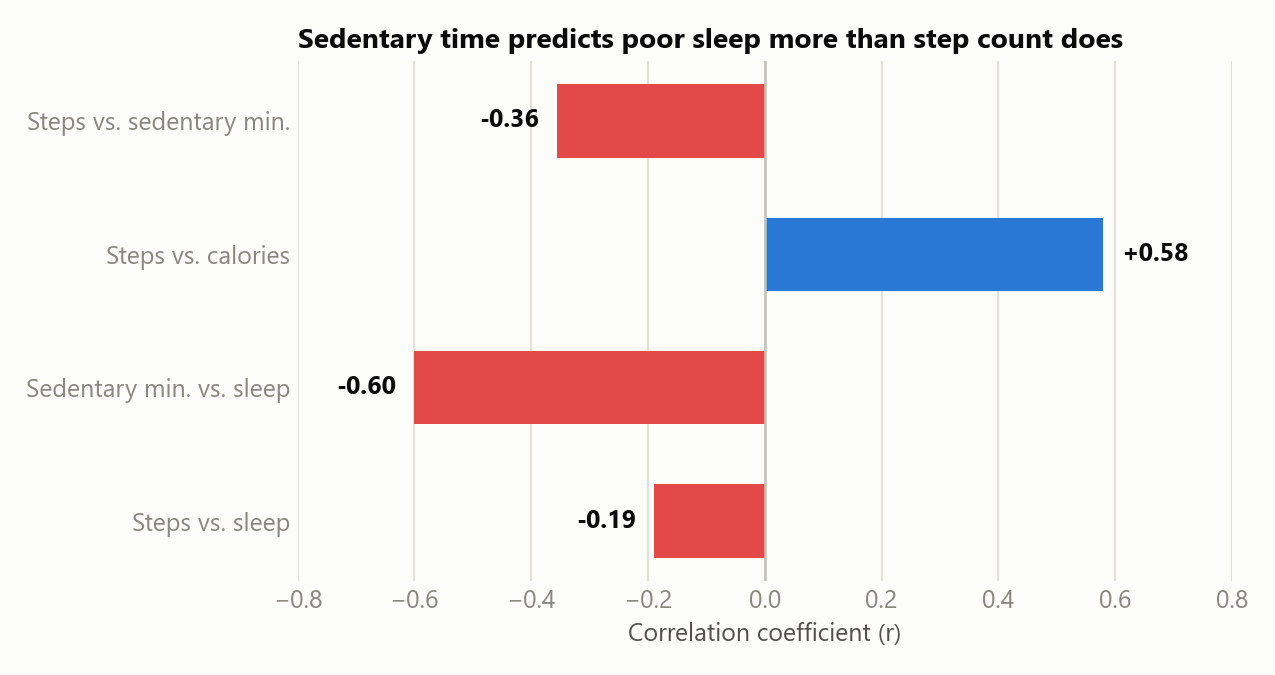

In [4]:
corr = pd.read_csv(os.path.join(SUMMARY_DIR, "correlations.csv")).set_index("pair").reindex([
    "steps vs sedentary_minutes", "steps vs calories",
    "sedentary_minutes vs minutes_asleep", "steps vs minutes_asleep",
])
corr_labels = ["Steps vs. sedentary min.", "Steps vs. calories", "Sedentary min. vs. sleep", "Steps vs. sleep"]
vals = corr["correlation"].values
colors_div = [BLUE if v >= 0 else RED for v in vals]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
y = range(len(corr_labels))
ax.barh(y, vals, color=colors_div, height=0.55)
for i, v in enumerate(vals):
    ax.text(v + (0.03 if v >= 0 else -0.03), i, f"{v:+.2f}", va="center",
             ha="left" if v >= 0 else "right", fontsize=12, color=INK_PRIMARY, fontweight="bold")
ax.set_yticks(list(y)); ax.set_yticklabels(corr_labels); ax.invert_yaxis()
ax.axvline(0, color=BASELINE, linewidth=1.2)
ax.set_xlim(-0.8, 0.8); ax.set_xlabel("Correlation coefficient (r)")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False); ax.spines["bottom"].set_visible(False)
ax.tick_params(length=0)
ax.xaxis.grid(True, color=GRID, linewidth=1); ax.set_axisbelow(True)
ax.set_title("Sedentary time predicts poor sleep more than step count does", fontsize=13.5,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "03_correlation_comparison.png"), dpi=150)
plt.show()

## 4. Sedentary time vs. sleep

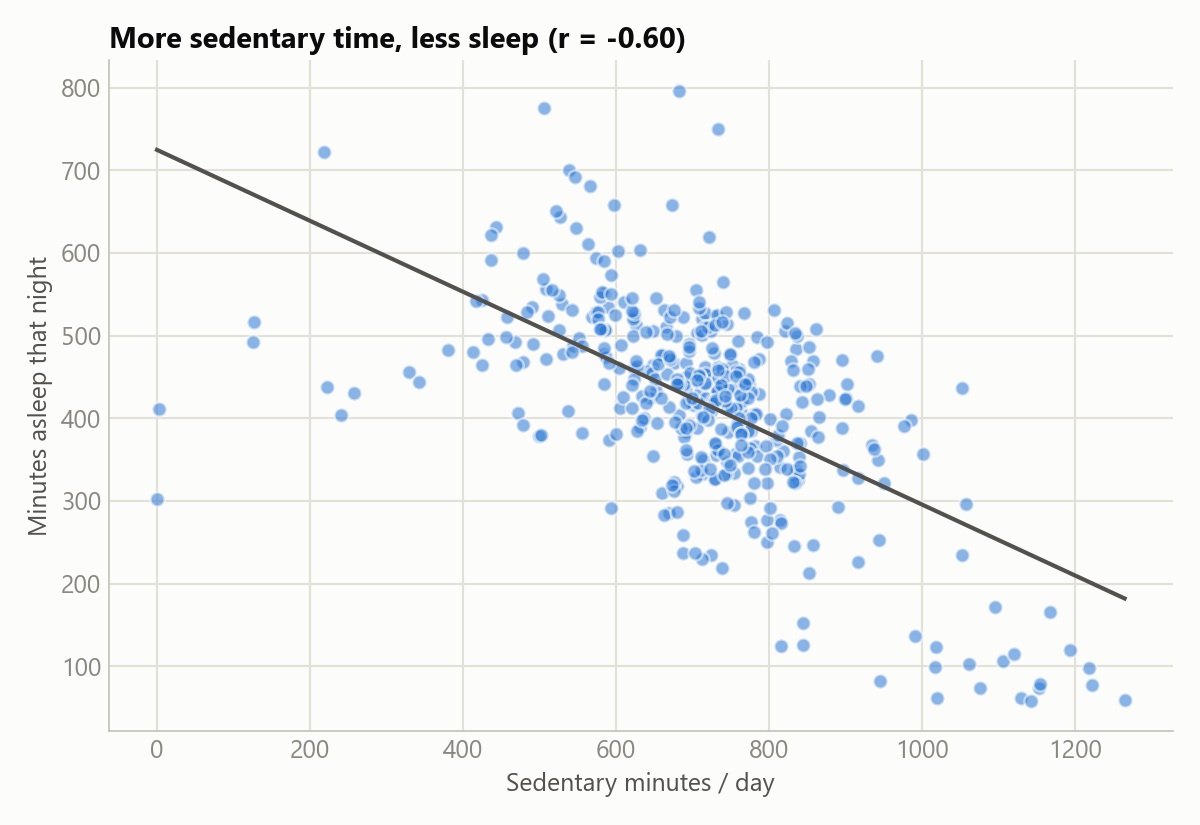

In [5]:
merged = pd.read_parquet(os.path.join(PROC_DIR, "activity_sleep_merged.parquet"))
sub = merged.dropna(subset=["total_minutes_asleep"])

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(sub["sedentary_minutes"], sub["total_minutes_asleep"], s=46, color=BLUE, alpha=0.55,
           edgecolor=SURFACE, linewidth=1.2, zorder=3)
z = np.polyfit(sub["sedentary_minutes"], sub["total_minutes_asleep"], 1)
xs = np.linspace(sub["sedentary_minutes"].min(), sub["sedentary_minutes"].max(), 50)
ax.plot(xs, np.polyval(z, xs), color=INK_SECONDARY, linewidth=2, zorder=4)
clean_axes(ax)
ax.xaxis.grid(True, color=GRID, linewidth=1); ax.yaxis.grid(True, color=GRID, linewidth=1)
ax.set_axisbelow(True)
ax.set_xlabel("Sedentary minutes / day"); ax.set_ylabel("Minutes asleep that night")
ax.set_title("More sedentary time, less sleep (r = -0.60)", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "04_sedentary_vs_sleep.png"), dpi=150)
plt.show()

## 5. Hourly activity pattern

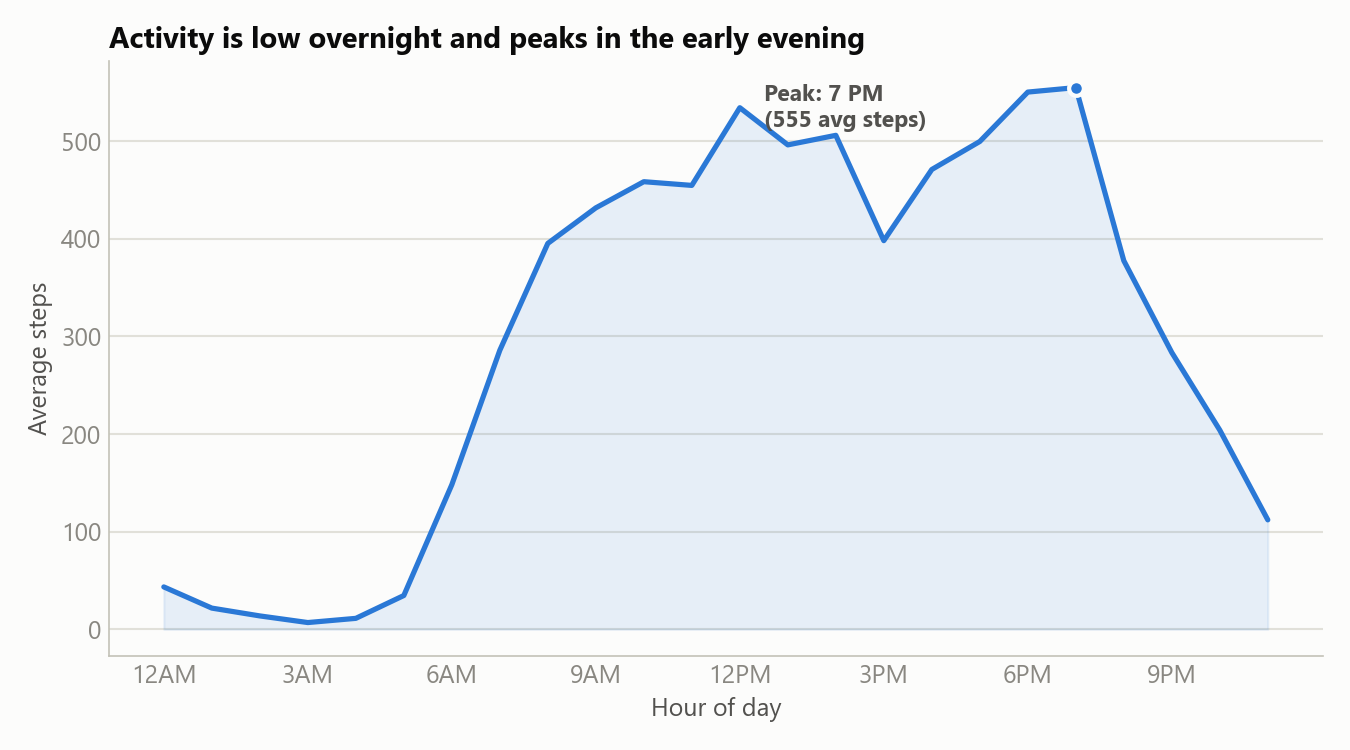

In [6]:
by_hour = pd.read_csv(os.path.join(SUMMARY_DIR, "steps_by_hour.csv"), index_col=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(by_hour.index, by_hour["step_total"], color=BLUE, linewidth=2.5, solid_capstyle="round")
ax.fill_between(by_hour.index, by_hour["step_total"], color=BLUE, alpha=0.10)
peak_hour = by_hour["step_total"].idxmax(); peak_val = by_hour["step_total"].max()
ax.scatter([peak_hour], [peak_val], s=50, color=BLUE, zorder=5, edgecolor=SURFACE, linewidth=2)
ax.annotate(f"Peak: 7 PM\n({peak_val:.0f} avg steps)", xy=(peak_hour, peak_val), xytext=(peak_hour-6.5, peak_val-40),
            fontsize=11, color=INK_SECONDARY, fontweight="bold")
ax.set_xticks(range(0, 24, 3))
ax.set_xticklabels(["12AM","3AM","6AM","9AM","12PM","3PM","6PM","9PM"])
clean_axes(ax)
ax.yaxis.grid(True, color=GRID, linewidth=1); ax.set_axisbelow(True)
ax.set_ylabel("Average steps"); ax.set_xlabel("Hour of day")
ax.set_title("Activity is low overnight and peaks in the early evening", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "05_hourly_activity.png"), dpi=150)
plt.show()

## Summary

The story across all five charts: **most users are under-active by step-count standards, spend
the large majority of their tracked day sedentary, and sedentary time — not step count — is what
tracks most closely with poor sleep.** See [`docs/05_share.md`](../docs/05_share.md) for the full
write-up.